In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import OneHotEncoder

In [2]:
ACHState = pd.read_csv('ACHbyState.csv')
CCbyState = pd.read_csv('CCbyState.csv')
Funding = pd.read_csv('CDC Epi Funding 2023.csv')

In [3]:
ACHState.columns = ACHState.columns.str.strip()
CCbyState.columns = CCbyState.columns.str.strip()
Funding.columns = Funding.columns.str.strip()

In [4]:
ACHState['State'] = ACHState['State'].astype("string")
CCbyState['State'] = CCbyState['State'].astype("string")
Funding['State'] = Funding['State'].astype("string")

columns_to_clean = [
    'Observed CLABSI', 'Predicted CLABSI',
    'Observed MRSA Infections', 'Predicted MRSA Infection',
    'Observed CAUTI', 'Predicted CAUTI',
    'Observed VAE', 'Predicted VAE'
]
for col in columns_to_clean:
    ACHState[col] = ACHState[col].astype(str).str.replace(',', '').replace(['.', '', ' . '], np.nan).astype(float)

Funding['Amount'] = Funding['Amount'].astype(str).str.findall(r'[\d,.]+').apply(
    lambda x: sum([float(i.replace(',', '')) for i in x]) if isinstance(x, list) else np.nan)

state_funding = Funding.groupby('State')['Amount'].sum().reset_index()
merged_data = ACHState.merge(CCbyState, on='State', how='left', suffixes=('_ACH', '_CC'))
merged_data = merged_data.merge(state_funding, on='State', how='left')


In [5]:
infection_types = {
    'MRSA': ('Observed MRSA Infections_ACH', 'Predicted MRSA Infection_ACH'),
    'CLABSI': ('Observed CLABSI_ACH', 'Predicted CLABSI_ACH'),
    'CAUTI': ('Observed CAUTI_ACH', 'Predicted CAUTI_ACH'),
    'VAE': ('Observed VAE_ACH', 'Predicted VAE_ACH')
}
for infection, (obs, pred) in infection_types.items():
    merged_data[f'{infection}_SIR'] = merged_data[obs] / merged_data[pred]
merged_data.replace([np.inf, -np.inf], np.nan, inplace=True)


/var/folders/6h/0xwz27g56m3d0bx7zm77q6wr0000gn/T/ipykernel_6159/4194495628.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=merged_data.sort_values('Amount', ascending=False), x='State', y='Amount', palette='magma')


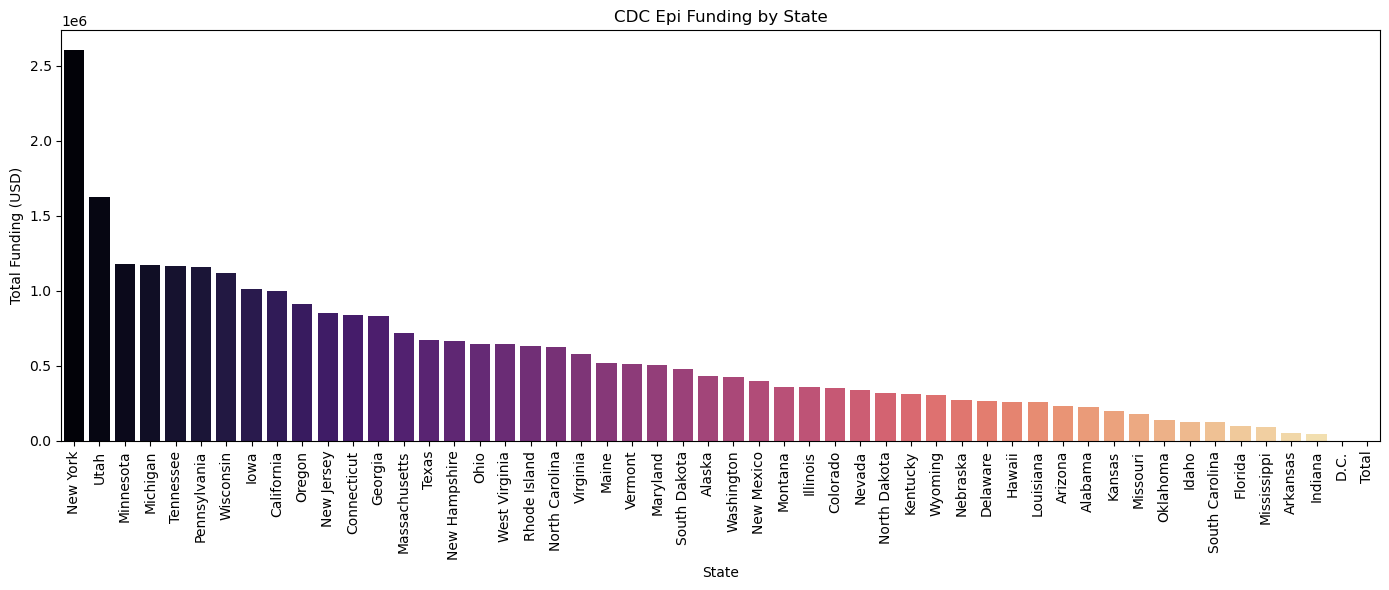

In [6]:
plt.figure(figsize=(14,6))
sns.barplot(data=merged_data.sort_values('Amount', ascending=False), x='State', y='Amount', palette='magma')
plt.xticks(rotation=90)
plt.title("CDC Epi Funding by State")
plt.ylabel("Total Funding (USD)")
plt.tight_layout()
plt.show()

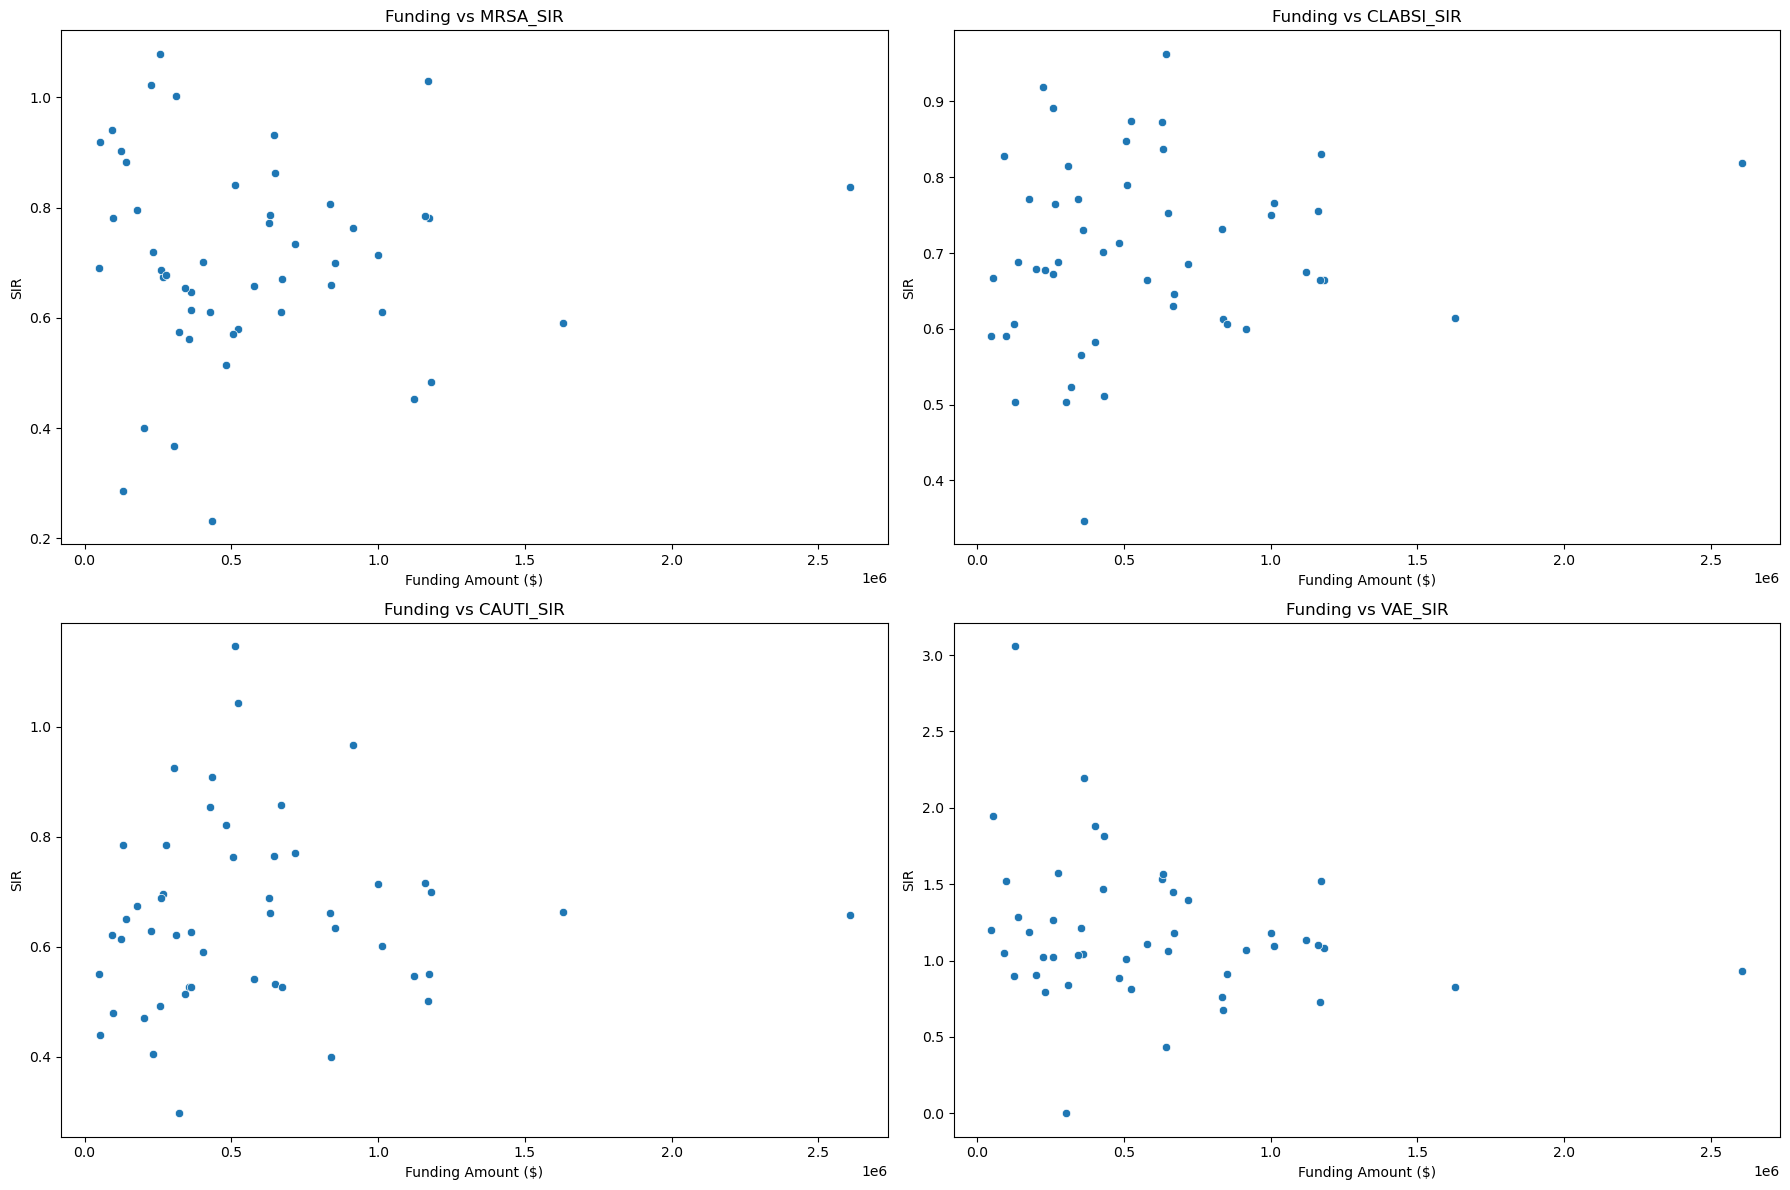

In [7]:
infection_sirs = ['MRSA_SIR', 'CLABSI_SIR', 'CAUTI_SIR', 'VAE_SIR']
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
for idx, infection in enumerate(infection_sirs):
    ax = axes[idx//2, idx%2]
    sns.scatterplot(data=merged_data, x='Amount', y=infection, ax=ax)
    ax.set_title(f'Funding vs {infection}')
    ax.set_xlabel('Funding Amount ($)')
    ax.set_ylabel('SIR')
plt.tight_layout()
plt.show()

In [8]:
median_funding = merged_data['Amount'].median()
low = merged_data[merged_data['Amount'] <= median_funding]
high = merged_data[merged_data['Amount'] > median_funding]
print("\nInferential Statistics:")
for infection in infection_sirs:
    if merged_data[infection].notna().sum() > 10:
        valid_data = merged_data[['Amount', infection]].dropna()
        pearson_r, pearson_p = stats.pearsonr(valid_data['Amount'], valid_data[infection])
        t_stat, t_p = stats.ttest_ind(
            low[infection].dropna(), high[infection].dropna(), nan_policy='omit')
        print(f"{infection} - Pearson r: {pearson_r:.3f}, p: {pearson_p:.3f} | T-test: t={t_stat:.3f}, p={t_p:.3f}")



Inferential Statistics:
MRSA_SIR - Pearson r: 0.010, p: 0.943 | T-test: t=-0.247, p=0.806
CLABSI_SIR - Pearson r: 0.150, p: 0.298 | T-test: t=-2.133, p=0.038
CAUTI_SIR - Pearson r: 0.076, p: 0.600 | T-test: t=-1.768, p=0.083
VAE_SIR - Pearson r: -0.231, p: 0.118 | T-test: t=1.861, p=0.069


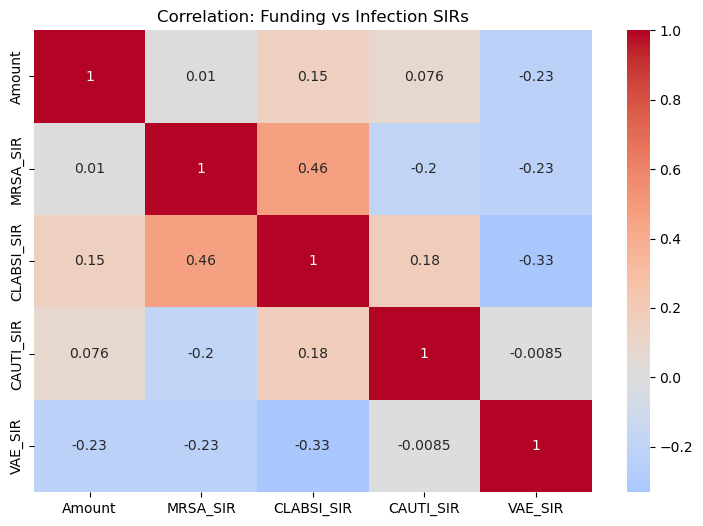

In [9]:
correlation_matrix = merged_data[['Amount'] + infection_sirs].corr()
plt.figure(figsize=(9, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation: Funding vs Infection SIRs')
plt.show()

### Linear

Linear Regression R²: -0.110
Linear Regression RMSE: 0.146


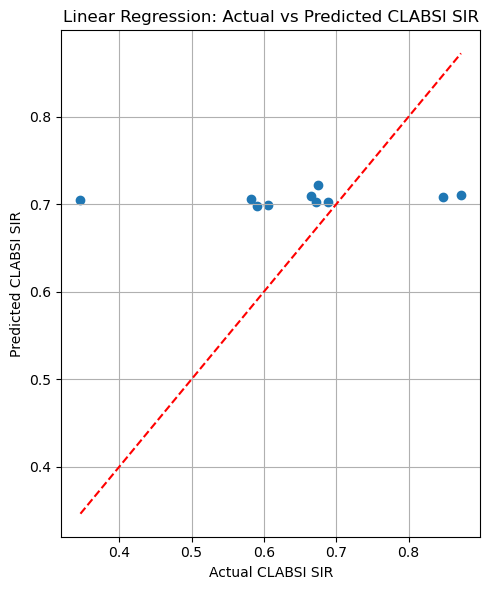

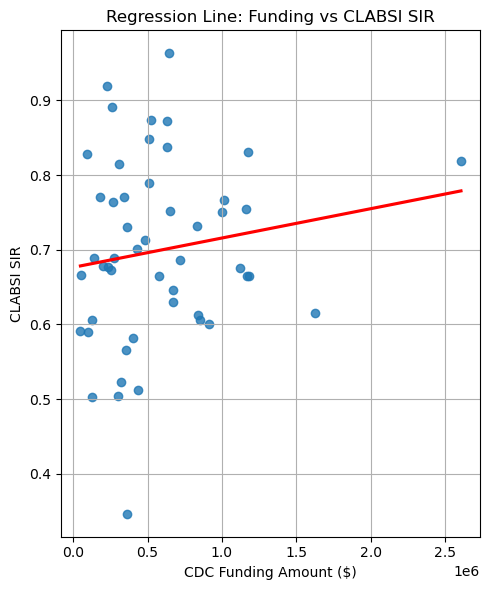

In [14]:
X = merged_data[['Amount']].dropna()
y = merged_data['CLABSI_SIR'].loc[X.index] 


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)


y_pred = lr_model.predict(X_test)


r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"Linear Regression R²: {r2:.3f}")
print(f"Linear Regression RMSE: {rmse:.3f}")


plt.figure(figsize=(5,6))
plt.scatter(y_test, y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual CLABSI SIR')
plt.ylabel('Predicted CLABSI SIR')
plt.title('Linear Regression: Actual vs Predicted CLABSI SIR')
plt.grid(True)
plt.tight_layout()
plt.show()


plt.figure(figsize=(5,6))
sns.regplot(x=X['Amount'], y=y, ci=None, line_kws={'color':'red'})
plt.xlabel('CDC Funding Amount ($)')
plt.ylabel('CLABSI SIR')
plt.title('Regression Line: Funding vs CLABSI SIR')
plt.grid(True)
plt.tight_layout()
plt.show()

### Random Forrest

Random Forest Regression R²: -0.183
Random Forest Regression RMSE: 0.151


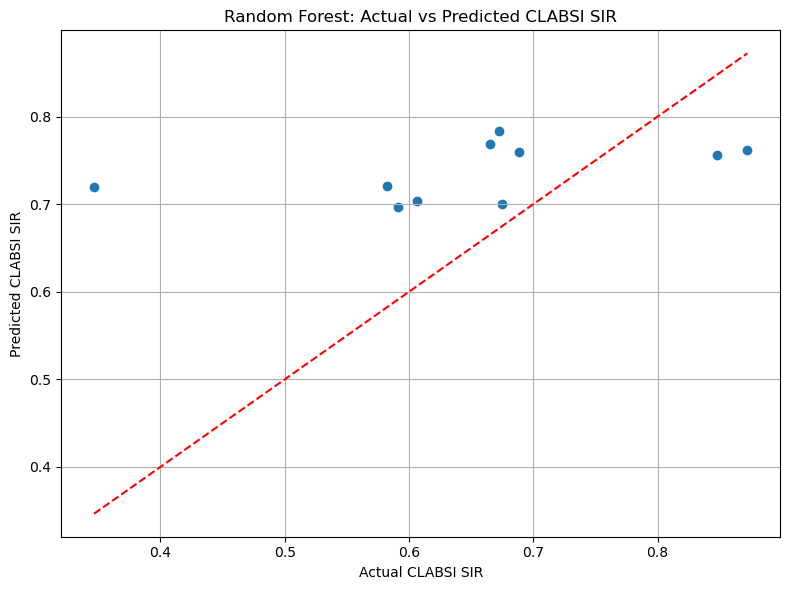

In [12]:
features = ['State', 'Amount'] 
data_rf = merged_data[features + ['CLABSI_SIR']].dropna()

encoder = OneHotEncoder(drop='first', sparse_output=False)
state_encoded = encoder.fit_transform(data_rf[['State']])
state_encoded_df = pd.DataFrame(state_encoded, columns=encoder.get_feature_names_out(['State']))

X_rf = pd.concat([state_encoded_df, data_rf[['Amount']].reset_index(drop=True)], axis=1)
y_rf = data_rf['CLABSI_SIR'].reset_index(drop=True)


X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(X_rf, y_rf, test_size=0.2, random_state=42)


rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train_rf, y_train_rf)

y_pred_rf = rf_model.predict(X_test_rf)

r2_rf = r2_score(y_test_rf, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test_rf, y_pred_rf))
print(f"Random Forest Regression R²: {r2_rf:.3f}")
print(f"Random Forest Regression RMSE: {rmse_rf:.3f}")

plt.figure(figsize=(8,6))
plt.scatter(y_test_rf, y_pred_rf)
plt.plot([y_test_rf.min(), y_test_rf.max()], [y_test_rf.min(), y_test_rf.max()], 'r--')
plt.xlabel('Actual CLABSI SIR')
plt.ylabel('Predicted CLABSI SIR')
plt.title('Random Forest: Actual vs Predicted CLABSI SIR')
plt.grid(True)
plt.tight_layout()
plt.show()

### Gradient Boosting

Gradient Boosting Regression R²: -0.228
Gradient Boosting Regression RMSE: 0.154


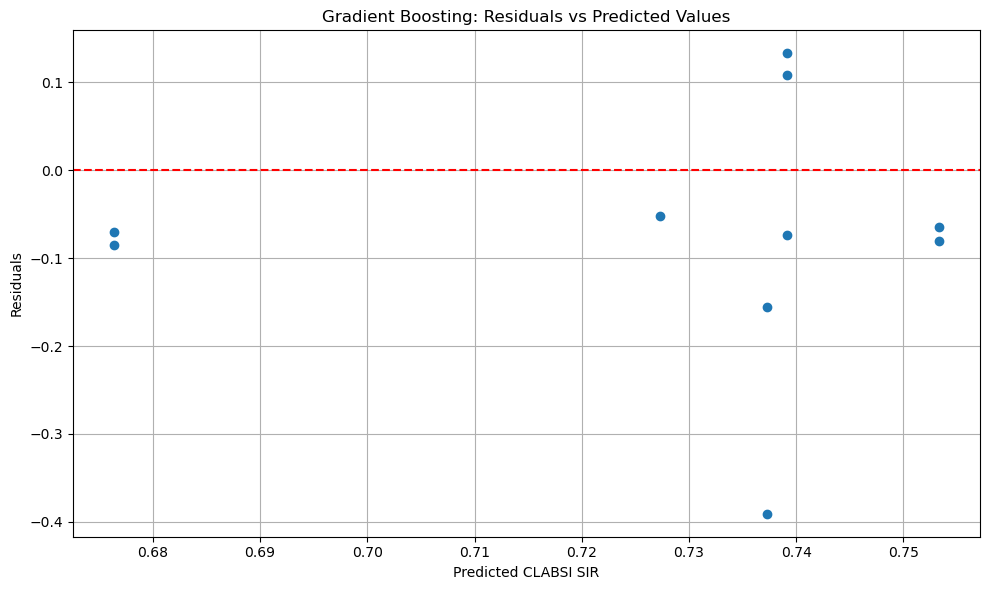

In [13]:
features = ['State', 'Amount']
data_gb = merged_data[features + ['CLABSI_SIR']].dropna()


encoder_gb = OneHotEncoder(drop='first', sparse_output=False)
state_encoded_gb = encoder_gb.fit_transform(data_gb[['State']])
state_encoded_df_gb = pd.DataFrame(state_encoded_gb, columns=encoder_gb.get_feature_names_out(['State']))


X_gb = pd.concat([state_encoded_df_gb, data_gb[['Amount']].reset_index(drop=True)], axis=1)
y_gb = data_gb['CLABSI_SIR'].reset_index(drop=True)


X_train_gb, X_test_gb, y_train_gb, y_test_gb = train_test_split(X_gb, y_gb, test_size=0.2, random_state=42)


gb_model = GradientBoostingRegressor(n_estimators=100, random_state=42)
gb_model.fit(X_train_gb, y_train_gb)


y_pred_gb = gb_model.predict(X_test_gb)


r2_gb = r2_score(y_test_gb, y_pred_gb)
rmse_gb = np.sqrt(mean_squared_error(y_test_gb, y_pred_gb))
print(f"Gradient Boosting Regression R²: {r2_gb:.3f}")
print(f"Gradient Boosting Regression RMSE: {rmse_gb:.3f}")


residuals = y_test_gb - y_pred_gb

plt.figure(figsize=(10,6))
plt.scatter(y_pred_gb, residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted CLABSI SIR')
plt.ylabel('Residuals')
plt.title('Gradient Boosting: Residuals vs Predicted Values')
plt.grid(True)
plt.tight_layout()
plt.show()